# Fine-Tuned Emotion Predictor - Test Visualization

This notebook tests the fine-tuned emotion prediction model on 5 test images and displays the predicted emotions alongside each image.


In [1]:
import torch
import torch.nn as nn
import clip
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path

# ArtEmis emotion order
ARTEMIS_EMOTIONS = [
    'amusement', 'awe', 'contentment', 'excitement',
    'anger', 'disgust', 'fear', 'sadness', 'something else'
]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


In [ ]:
# Load CLIP model
print("Loading CLIP model (RN50x16)...")
clip_model, preprocess = clip.load("RN50x16", device=device)
clip_model.eval()
print("✓ CLIP loaded")

# Load fine-tuned emotion predictor
from emotionpredictor.training import SLP

print("Loading fine-tuned emotion predictor...")
emotion_model = SLP(input_size=768, output_size=9).to(device)
emotion_model.load_state_dict(
    torch.load("neural_checkpoints/finetuned_emotion_predictor_model", map_location=device)
)
emotion_model.eval()
print("✓ Fine-tuned model loaded")


Loading CLIP model (RN50x16)...


✓ CLIP loaded


Loading fine-tuned emotion predictor...
✓ Fine-tuned model loaded


In [ ]:
# Load test images
test_image_dir = Path("test_images")
test_images = sorted(list(test_image_dir.glob("*.png")))

print(f"Found {len(test_images)} test images:")
for img_path in test_images:
    print(f"  - {img_path.name}")


Found 5 test images:
  - image1.png
  - image2.png
  - image3.png
  - image4.png
  - image5.png


In [ ]:
def predict_emotions(image_path, clip_model, emotion_model, preprocess, device):
    """Predict emotions for a single image."""
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Extract CLIP embedding
    with torch.no_grad():
        clip_features = clip_model.encode_image(image_tensor)
        
        # Get emotion predictions
        emotion_logits = emotion_model(clip_features)
        emotion_probs = torch.softmax(emotion_logits, dim=1)[0].cpu().numpy()
    
    return image, emotion_probs



image1.png:
  Top emotion: contentment (0.707)
  Top 3 emotions:
    1. contentment: 0.707
    2. sadness: 0.247
    3. excitement: 0.013



image2.png:
  Top emotion: contentment (0.824)
  Top 3 emotions:
    1. contentment: 0.824
    2. sadness: 0.151
    3. excitement: 0.011



image3.png:
  Top emotion: sadness (0.513)
  Top 3 emotions:
    1. sadness: 0.513
    2. contentment: 0.444
    3. excitement: 0.019



image4.png:
  Top emotion: sadness (0.572)
  Top 3 emotions:
    1. sadness: 0.572
    2. contentment: 0.338
    3. amusement: 0.034



image5.png:
  Top emotion: contentment (0.512)
  Top 3 emotions:
    1. contentment: 0.512
    2. sadness: 0.439
    3. excitement: 0.021



✓ Visualization saved to 'test_predictions.png'


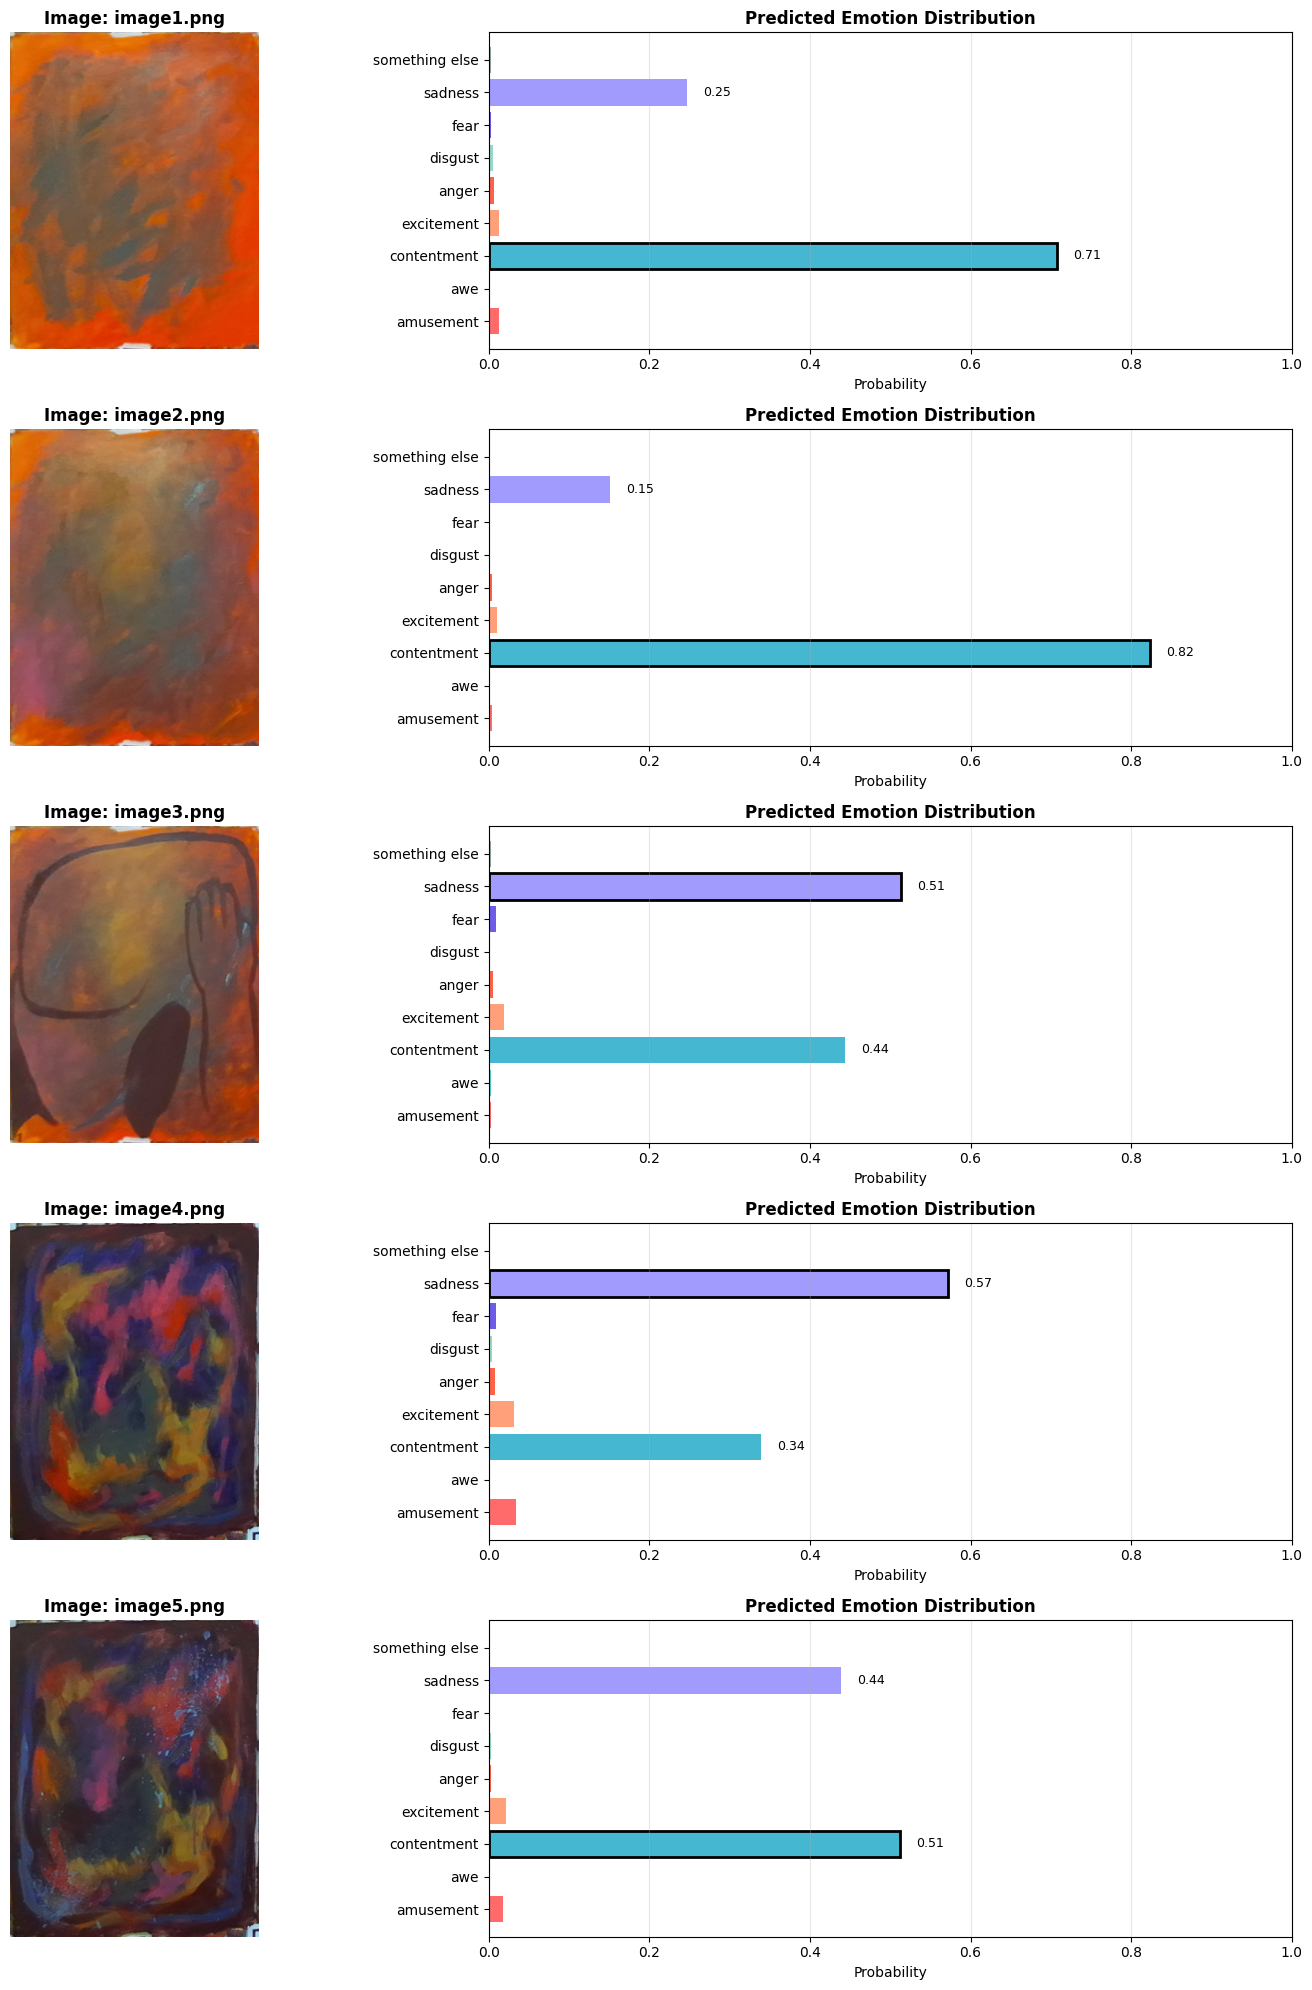

In [ ]:
# Create visualization for all test images
fig, axes = plt.subplots(len(test_images), 2, figsize=(16, 4 * len(test_images)))

if len(test_images) == 1:
    axes = axes.reshape(1, -1)

for idx, image_path in enumerate(test_images):
    # Get predictions
    image, emotion_probs = predict_emotions(
        image_path, clip_model, emotion_model, preprocess, device
    )
    
    # Display image
    axes[idx, 0].imshow(image)
    axes[idx, 0].axis('off')
    axes[idx, 0].set_title(f"Image: {image_path.name}", fontsize=12, fontweight='bold')
    
    # Display emotion predictions as bar chart
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', 
              '#FF6347', '#98D8C8', '#6C5CE7', '#A29BFE', '#95A5A6']
    
    bars = axes[idx, 1].barh(ARTEMIS_EMOTIONS, emotion_probs, color=colors)
    axes[idx, 1].set_xlim(0, 1)
    axes[idx, 1].set_xlabel('Probability', fontsize=10)
    axes[idx, 1].set_title('Predicted Emotion Distribution', fontsize=12, fontweight='bold')
    axes[idx, 1].grid(axis='x', alpha=0.3)
    
    # Add probability values on bars
    for i, (emotion, prob) in enumerate(zip(ARTEMIS_EMOTIONS, emotion_probs)):
        if prob > 0.05:  # Only show if probability > 5%
            axes[idx, 1].text(prob + 0.02, i, f'{prob:.2f}', 
                            va='center', fontsize=9)
    
    # Highlight top emotion
    top_idx = np.argmax(emotion_probs)
    bars[top_idx].set_edgecolor('black')
    bars[top_idx].set_linewidth(2)
    
    print(f"\n{image_path.name}:")
    print(f"  Top emotion: {ARTEMIS_EMOTIONS[top_idx]} ({emotion_probs[top_idx]:.3f})")
    print(f"  Top 3 emotions:")
    top_3_indices = np.argsort(emotion_probs)[-3:][::-1]
    for i, top_idx in enumerate(top_3_indices, 1):
        print(f"    {i}. {ARTEMIS_EMOTIONS[top_idx]}: {emotion_probs[top_idx]:.3f}")

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualization saved to 'test_predictions.png'")
plt.show()


In [ ]:
# Summary statistics
print("=" * 60)
print("SUMMARY OF PREDICTIONS")
print("=" * 60)

all_predictions = []
for image_path in test_images:
    _, emotion_probs = predict_emotions(
        image_path, clip_model, emotion_model, preprocess, device
    )
    all_predictions.append(emotion_probs)
    top_idx = np.argmax(emotion_probs)
    print(f"{image_path.name:30s} → {ARTEMIS_EMOTIONS[top_idx]:15s} ({emotion_probs[top_idx]:.3f})")

all_predictions = np.array(all_predictions)
avg_probs = all_predictions.mean(axis=0)

print("\n" + "=" * 60)
print("AVERAGE EMOTION DISTRIBUTION ACROSS ALL TEST IMAGES")
print("=" * 60)
for emotion, prob in zip(ARTEMIS_EMOTIONS, avg_probs):
    print(f"{emotion:15s}: {prob:.3f}")


SUMMARY OF PREDICTIONS


image1.png                     → contentment     (0.707)


image2.png                     → contentment     (0.824)


image3.png                     → sadness         (0.513)


image4.png                     → sadness         (0.572)


image5.png                     → contentment     (0.512)

AVERAGE EMOTION DISTRIBUTION ACROSS ALL TEST IMAGES
amusement      : 0.014
awe            : 0.002
contentment    : 0.565
excitement     : 0.019
anger          : 0.005
disgust        : 0.003
fear           : 0.005
sadness        : 0.384
something else : 0.002
